# Entails a CNN for image and data classification
-This notebook develops a CNN model to classify disaster images into fire, flood and normal cartegory in a business management system
-Various data sets from kaggle
-Mainly focuses on flood,fire,damage and even satellite imagery

In [3]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [6]:
import os
print("Current working directory:")
print(os.getcwd())

Current working directory:
/home/lennoxlewis/Desktop/Projects/ResiliAI/Notebooks


In [7]:
train_dir = "../Data/Train"
val_dir = "../Data/Val"
test_dir = "../Data/Test"

print("Train exists:", os.path.exists(train_dir))
print("Val exists:", os.path.exists(val_dir))
print("Test exists:", os.path.exists(test_dir))

Train exists: True
Val exists: True
Test exists: True


In [8]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['Damage', 'Fire', 'Flood']


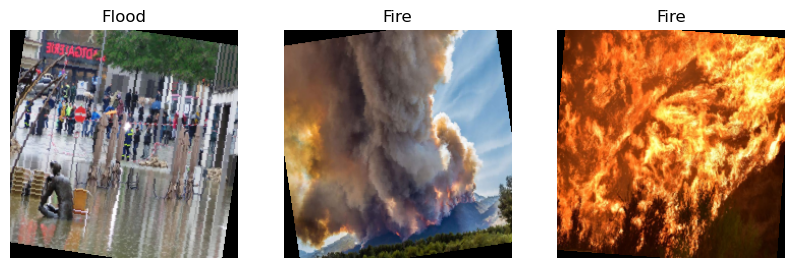

In [9]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))
for i in range(3):
    plt.subplot(1,3,i+1)
    img = images[i].permute(1,2,0).numpy()
    img = (img * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()


In [ ]:
class DisasterCNN(nn.Module):
    def __init__(self):
        super(DisasterCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 3)   # 3 classes
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [11]:
model = DisasterCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
num_epochs = 10

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_loss:.4f} "
          f"Val Loss: {val_loss:.4f}")

Epoch [1/10] Train Loss: 0.4562 Val Loss: 0.5966
Epoch [2/10] Train Loss: 0.1658 Val Loss: 0.3461
Epoch [3/10] Train Loss: 0.1027 Val Loss: 0.3725
Epoch [4/10] Train Loss: 0.1049 Val Loss: 0.3250
Epoch [5/10] Train Loss: 0.0817 Val Loss: 0.4223
Epoch [6/10] Train Loss: 0.0714 Val Loss: 0.2883
Epoch [7/10] Train Loss: 0.0459 Val Loss: 0.3532
Epoch [8/10] Train Loss: 0.0527 Val Loss: 0.4017
Epoch [9/10] Train Loss: 0.0796 Val Loss: 0.2004
Epoch [10/10] Train Loss: 0.0508 Val Loss: 0.3328


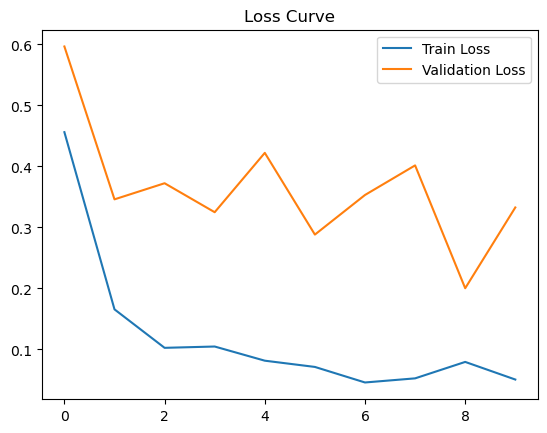

In [14]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

In [15]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [16]:
print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

      Damage       1.00      0.25      0.40       155
        Fire       0.93      0.92      0.93       297
       Flood       0.55      0.98      0.70       151

    accuracy                           0.76       603
   macro avg       0.83      0.72      0.68       603
weighted avg       0.85      0.76      0.74       603



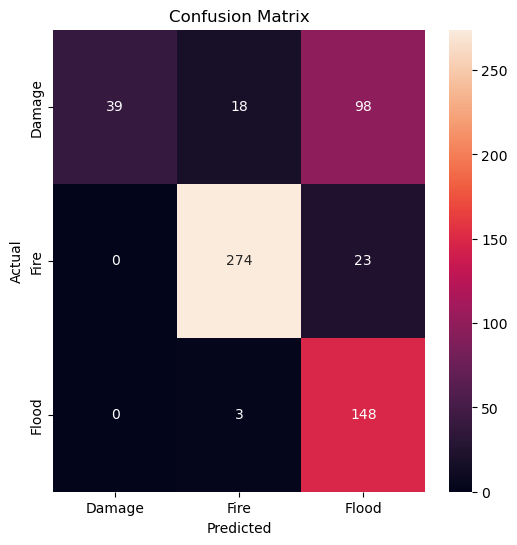

In [17]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [18]:
os.makedirs("../models", exist_ok=True)
torch.save(model.state_dict(), "../models/disaster_cnn.pth")
print("Model saved successfully.")

Model saved successfully.
